In [ ]:
#Estado compartido
class State:
    customer_name: str
    my_age: int
    mensaje: str
    
state: State = {}
customer_name = state.get("customer_name", None)
print(f"Hello {customer_name}!")

Hello None!


In [2]:
#Nodo
def node_1(state: State):
    if state.get("customer_name") is None:
        return {"customer_name": "Alice"}    #actualiza el estado compartido
    return {}

In [ ]:
def node_2(state: State):
    edad = state.get("my_age", None)
    if edad >= 18:
        print("You are an adult.")
    else: print("You are a minor.")

In [4]:
from langgraph.graph import StateGraph, START, END

builder = StateGraph(State)
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)
builder.add_edge(START, "node_1")
builder.add_edge("node_1", "node_2")
builder.add_edge("node_2", END)

agent = builder.compile()

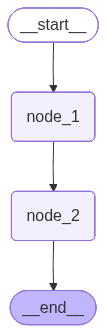

In [7]:
from IPython.display import Image, display
display(Image(agent.get_graph().draw_mermaid_png()))
#rint(agent.get_graph().draw_ascii())